In [78]:
import pandas as pd
import networkx as nx
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [79]:
data = pd.read_csv('../../data/data/processed/fdemand.csv')

In [80]:
data_no3000 = data[data['end_station'] != 3000]

In [81]:
data_no3000.head()

,duration,start_station,end_station,plan_duration,st_year,st_month,st_day,st_hour,st_minute,end_year,...,end_name,end_lat,end_lon,dist_km,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,11,3049,3072,30,2020,1,1,0,13,2020,...,Front & Carpenter,39.93445,-75.14541,1.208846,9.17,0.0,0.0,0.0,42,29
1,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
2,28,3124,3053,30,2020,1,1,0,14,2020,...,Point Breeze & Tasker,39.93231,-75.18154,4.295275,9.17,0.0,0.0,0.0,42,29
3,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29
4,21,3005,3018,30,2020,1,1,0,17,2020,...,12th & Filbert,39.95273,-75.15979,1.471505,9.17,0.0,0.0,0.0,42,29


## for all dates :~

### Making the Data Set

In [82]:
# Define all_station_coords_df_full
# Extract unique station coordinates from the main data
# We'll combine start and end station information to get a comprehensive list.

# Collect start station info (without 'start_name' as it's missing)
start_stations = data[['start_station', 'st_lat', 'st_lon']].drop_duplicates().copy()
start_stations.rename(columns={'start_station': 'station_id',
                               'st_lat': 'latitude',
                               'st_lon': 'longitude'}, inplace=True)
# Add a placeholder for station_name for start_stations
start_stations['station_name'] = None

# Collect end station info (with 'end_name')
end_stations = data[['end_station', 'end_lat', 'end_lon', 'end_name']].drop_duplicates().copy()
end_stations.rename(columns={'end_station': 'station_id',
                             'end_lat': 'latitude',
                             'end_lon': 'longitude',
                             'end_name': 'station_name'}, inplace=True)

# Combine and remove duplicates to get all unique station coordinates and names
# Use a common set of columns for concat to ensure they align
all_station_coords_df_full = pd.concat([start_stations[['station_id', 'latitude', 'longitude', 'station_name']],
                                        end_stations[['station_id', 'latitude', 'longitude', 'station_name']]]) \
                            .drop_duplicates(subset=['station_id']).reset_index(drop=True)

# Ensure station_id is integer type for consistent merging
all_station_coords_df_full['station_id'] = all_station_coords_df_full['station_id'].astype(int)


# Preprocessing: Calculate daily net change per station from data_no3000
# Ensure 'st_year', 'st_month', 'st_day' are used to create a date column
# This assumes data_no3000 contains 'start_station', 'end_station', 'st_year', 'st_month', 'st_day'

# Create a daily identifier
# Make a copy to avoid SettingWithCopyWarning
data_for_net_change = data_no3000.copy()
data_for_net_change['date'] = pd.to_datetime({'year': data_for_net_change['st_year'], 'month': data_for_net_change['st_month'], 'day': data_for_net_change['st_day']})

# Count bikes leaving each station per day
departures = data_for_net_change.groupby(['date', 'start_station']).size().reset_index(name='departures')
departures.rename(columns={'start_station': 'station_id'}, inplace=True)

# Count bikes arriving at each station per day
arrivals = data_for_net_change.groupby(['date', 'end_station']).size().reset_index(name='arrivals')
arrivals.rename(columns={'end_station': 'station_id'}, inplace=True)

# Merge departures and arrivals
daily_station_activity = pd.merge(departures, arrivals, on=['date', 'station_id'], how='outer').fillna(0)

# Calculate net change
daily_station_activity['net_change'] = daily_station_activity['arrivals'] - daily_station_activity['departures']

In [83]:
# 1. Create a directed graph representing the bike-sharing network
G = nx.DiGraph()

# Add all unique stations as nodes
all_unique_stations = pd.concat([data_no3000['start_station'], data_no3000['end_station']]).unique()
G.add_nodes_from(all_unique_stations)

# Add edges with weights (number of trips) between start and end stations
trip_counts = data_no3000.groupby(['start_station', 'end_station']).size().reset_index(name='trip_count')

for _, row in trip_counts.iterrows():
    G.add_edge(row['start_station'], row['end_station'], weight=row['trip_count'])

In [84]:
# 2. Calculate Centrality Measures
centrality_measures = {
    'station_id': [],
    'degree_centrality_in': [],
    'degree_centrality_out': [],
    'betweenness_centrality_unweighted': [],
    'closeness_centrality_unweighted': [],
    'eigenvector_centrality_weighted': []
}

in_degree_centrality = nx.in_degree_centrality(G)
out_degree_centrality = nx.out_degree_centrality(G)

# Use unweighted centrality for betweenness and closeness for a standard interpretation of 'paths'
betweenness_unweighted = nx.betweenness_centrality(G)
closeness_unweighted = nx.closeness_centrality(G)

# Use weighted eigenvector centrality, where higher trip count means more influence
try:
    eigenvector_weighted = nx.eigenvector_centrality(G, weight='weight', max_iter=1000, tol=1e-06)
except nx.PowerIterationFailedConvergence:
    print("Eigenvector centrality did not converge for some nodes. Assigning 0 to non-converged nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}
except Exception as e:
    print(f"Error calculating eigenvector centrality: {e}. Assigning 0 to all nodes.")
    eigenvector_weighted = {node: 0 for node in G.nodes()}

for station_id in G.nodes():
    centrality_measures['station_id'].append(station_id)
    centrality_measures['degree_centrality_in'].append(in_degree_centrality.get(station_id, 0))
    centrality_measures['degree_centrality_out'].append(out_degree_centrality.get(station_id, 0))
    centrality_measures['betweenness_centrality_unweighted'].append(betweenness_unweighted.get(station_id, 0))
    centrality_measures['closeness_centrality_unweighted'].append(closeness_unweighted.get(station_id, 0))
    centrality_measures['eigenvector_centrality_weighted'].append(eigenvector_weighted.get(station_id, 0))

station_centrality_df = pd.DataFrame(centrality_measures)

In [85]:
# 3. Prepare base DataFrame for modeling: `daily_station_activity`
# This DataFrame contains 'date', 'station_id', 'departures', 'arrivals', 'net_change'
modeling_df = daily_station_activity.copy()

In [86]:
# 4. Add Time-based Features
modeling_df['weekday'] = modeling_df['date'].dt.weekday # Monday=0, Sunday=6
modeling_df['dayofyear'] = modeling_df['date'].dt.dayofyear
modeling_df['month'] = modeling_df['date'].dt.month
modeling_df['is_weekend'] = modeling_df['date'].dt.weekday.isin([5, 6])

In [87]:
# 5. Aggregate Daily Weather Data
# Create a 'date' column in data_no3000 to merge with modeling_df
weather_data_temp = data_no3000.copy()
weather_data_temp['date'] = pd.to_datetime({'year': weather_data_temp['st_year'], 'month': weather_data_temp['st_month'], 'day': weather_data_temp['st_day']})

weather_features = weather_data_temp.groupby('date')[['avg_wind', 'precip', 'snow', 'snow_ground', 'max_temp', 'min_temp']].mean().reset_index()

In [88]:
# 6. Merge all features into the modeling_df
# Merge centrality measures
modeling_df = pd.merge(modeling_df, station_centrality_df, on='station_id', how='left')

# Merge weather features
modeling_df = pd.merge(modeling_df, weather_features, on='date', how='left')

# Handle potential NaNs after merging
# Fill centrality NaNs with 0 (e.g., if a station existed in daily_station_activity but not in the graph)
centrality_cols = [col for col in station_centrality_df.columns if col != 'station_id']
for col in centrality_cols:
    modeling_df[col] = modeling_df[col].fillna(0)

# Fill weather NaNs, assuming weather features are generally available. Forward fill, then fill remaining with 0 or mean.
modeling_df.sort_values(by=['date', 'station_id'], inplace=True)
modeling_df[weather_features.columns.drop('date')] = modeling_df[weather_features.columns.drop('date')].ffill()
# Fill any remaining NaNs at the beginning of the series or if ffill couldn't propagate
modeling_df[weather_features.columns.drop('date')] = modeling_df[weather_features.columns.drop('date')].fillna(0)

In [89]:
# Display the head and info of the prepared dataset
print("Prepared dataset for XGBoost model (first 5 rows):")
display(modeling_df.head())

Prepared dataset for XGBoost model (first 5 rows):


,date,station_id,departures,arrivals,net_change,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
0,2020-01-01,3004,2.0,2.0,0.0,2,1,1,False,0.610465,0.607558,0.000245,0.714643,0.022472,9.17,0.0,0.0,0.0,42.0,29.0
1,2020-01-01,3005,10.0,2.0,-8.0,2,1,1,False,0.834302,0.834302,0.001171,0.853601,0.051949,9.17,0.0,0.0,0.0,42.0,29.0
2,2020-01-01,3006,3.0,4.0,1.0,2,1,1,False,0.857558,0.845930,0.002645,0.871201,0.066821,9.17,0.0,0.0,0.0,42.0,29.0
3,2020-01-01,3007,3.0,7.0,4.0,2,1,1,False,0.886628,0.895349,0.002138,0.894249,0.172888,9.17,0.0,0.0,0.0,42.0,29.0
4,2020-01-01,3008,1.0,1.0,0.0,2,1,1,False,0.694767,0.764535,0.001102,0.761320,0.010123,9.17,0.0,0.0,0.0,42.0,29.0


In [90]:
print("\nInformation about the prepared dataset:")
modeling_df.info()


Information about the prepared dataset:
<class 'pandas.DataFrame'>
RangeIndex: 449633 entries, 0 to 449632
Data columns (total 20 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   date                               449633 non-null  datetime64[us]
 1   station_id                         449633 non-null  int64         
 2   departures                         449633 non-null  float64       
 3   arrivals                           449633 non-null  float64       
 4   net_change                         449633 non-null  float64       
 5   weekday                            449633 non-null  int32         
 6   dayofyear                          449633 non-null  int32         
 7   month                              449633 non-null  int32         
 8   is_weekend                         449633 non-null  bool          
 9   degree_centrality_in               449633 non-null  float64   

### starting to model NET CHANGE

In [91]:
# Define features (X) and target (y)
# Drop 'date', 'departures', 'arrivals' as 'net_change' is derived from them and 'date' is encoded into other features.
features = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
target = modeling_df['net_change']

# Convert boolean 'is_weekend' to int for XGBoost compatibility
features['is_weekend'] = features['is_weekend'].astype(int)

In [92]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

In [93]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (359706, 15)
X_test shape: (89927, 15)
y_train shape: (359706,)
y_test shape: (89927,)


In [94]:
# Initialize and train the XGBoost Regressor model
# Using default parameters for a quick initial model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', # For regression tasks
    n_estimators=100,             # Number of boosting rounds
    learning_rate=0.1,            # Step size shrinkage to prevent overfitting
    random_state=42
)

print("\nTraining XGBoost model...")
xgb_model.fit(X_train, y_train)
print("XGBoost model training complete.")


Training XGBoost model...
XGBoost model training complete.


In [95]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- XGBoost Model Performance ---")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"R-squared (R2): {r2:.3f}")


--- XGBoost Model Performance ---
Mean Absolute Error (MAE): 2.506
R-squared (R2): 0.050


In [96]:
# Display feature importance
print("\n--- Feature Importance ---")
feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False)
display(feature_importances.head(10))


--- Feature Importance ---


,feature,importance
5,degree_centrality_out,0.214458
8,eigenvector_centrality_weighted,0.160094
6,betweenness_centrality_unweighted,0.142355
0,weekday,0.106208
4,degree_centrality_in,0.093231
2,month,0.048203
13,max_temp,0.041994
10,precip,0.036919
14,min_temp,0.036854
1,dayofyear,0.035664


end of xgboost

In [97]:
import numpy as np

# Apply ceiling to predictions to round up to the nearest whole number
y_pred_rounded = np.ceil(y_pred)

# Create a comparison DataFrame with rounded predictions
predictions_comparison_rounded = pd.DataFrame({'Actual Net Change': y_test, 'Predicted Net Change (Rounded)': y_pred_rounded})
display(predictions_comparison_rounded.head())

,Actual Net Change,Predicted Net Change (Rounded)
128103,-1.0,2.0
181342,5.0,1.0
144705,2.0,-0.0
319550,1.0,-0.0
320158,-1.0,1.0


--- XGBoost Model Performance (Rounded Predictions) ---
Mean Absolute Error (MAE) with rounding: 2.554
R-squared (R2) with rounding: 0.022


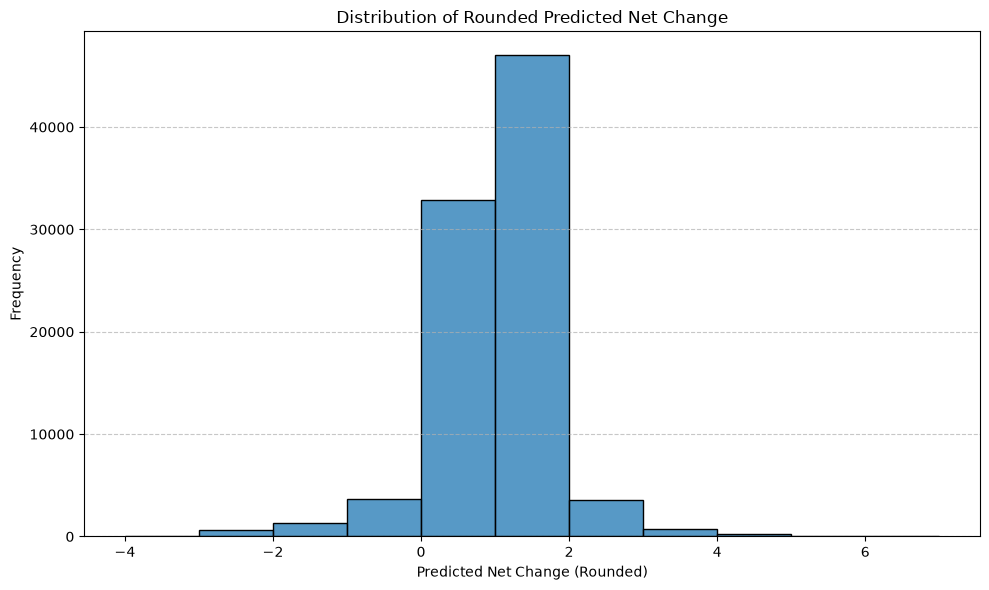

In [98]:
# Re-evaluate the model with the rounded predictions
mae_rounded = mean_absolute_error(y_test, y_pred_rounded)
r2_rounded = r2_score(y_test, y_pred_rounded)

print("--- XGBoost Model Performance (Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE) with rounding: {mae_rounded:.3f}")
print(f"R-squared (R2) with rounding: {r2_rounded:.3f}")

# You can also look at the distribution of the rounded predictions
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_pred_rounded, bins=np.arange(y_pred_rounded.min(), y_pred_rounded.max() + 1))
plt.title('Distribution of Rounded Predicted Net Change')
plt.xlabel('Predicted Net Change (Rounded)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### XGBoost Model for Predicting Whole Number of Arrivals with Rounding

In [99]:
# Define target for Arrivals model
target_arrivals = modeling_df['arrivals']

# Features for Arrivals model (exclude arrivals and departures and net_change)
features_arrivals = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_arrivals['is_weekend'] = features_arrivals['is_weekend'].astype(int)

In [100]:
# Split data for Arrivals model
X_train_arrivals, X_test_arrivals, y_train_arrivals, y_test_arrivals = train_test_split(
    features_arrivals, target_arrivals, test_size=0.2, random_state=42
)

print("X_train_arrivals shape:", X_train_arrivals.shape)
print("X_test_arrivals shape:", X_test_arrivals.shape)
print("y_train_arrivals shape:", y_train_arrivals.shape)
print("y_test_arrivals shape:", y_test_arrivals.shape)

X_train_arrivals shape: (359706, 15)
X_test_arrivals shape: (89927, 15)
y_train_arrivals shape: (359706,)
y_test_arrivals shape: (89927,)


In [101]:
# Initialize and train the XGBoost Regressor for Arrivals
xgb_arrivals_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Arrivals...")
xgb_arrivals_model.fit(X_train_arrivals, y_train_arrivals)
print("XGBoost model for Arrivals training complete.")


Training XGBoost model for Arrivals...
XGBoost model for Arrivals training complete.


In [102]:
# Make predictions and round to nearest whole number (and ensure non-negative)
# 1. Normal predictions (raw output from the model)
y_pred_arrivals_normal = xgb_arrivals_model.predict(X_test_arrivals)

# 2. Standard Round predictions
y_pred_arrivals_standard_rounded = np.round(y_pred_arrivals_normal)
y_pred_arrivals_standard_rounded[y_pred_arrivals_standard_rounded < 0] = 0 # Ensure no negative predictions for counts

# 3. Floor Round predictions
y_pred_arrivals_floor_rounded = np.floor(y_pred_arrivals_normal)
y_pred_arrivals_floor_rounded[y_pred_arrivals_floor_rounded < 0] = 0 # Ensure no negative predictions for counts

# 4. Ceiling Round predictions
y_pred_arrivals_ceil_rounded = np.ceil(y_pred_arrivals_normal)
y_pred_arrivals_ceil_rounded[y_pred_arrivals_ceil_rounded < 0] = 0 # Ensure no negative predictions for counts

In [103]:
# Evaluate the Arrivals model on the full dataset

# 1. Normal Predictions
mae_arrivals_normal_full = mean_absolute_error(y_test_arrivals, y_pred_arrivals_normal)
r2_arrivals_normal_full = r2_score(y_test_arrivals, y_pred_arrivals_normal)

print("\n--- XGBoost Model Performance (Arrivals - Normal Predictions, Full Data) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_normal_full:.3f}")
print(f"R-squared (R2): {r2_arrivals_normal_full:.3f}")

# 2. Standard Rounded Predictions
mae_arrivals_standard_rounded_full = mean_absolute_error(y_test_arrivals, y_pred_arrivals_standard_rounded)
r2_arrivals_standard_rounded_full = r2_score(y_test_arrivals, y_pred_arrivals_standard_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Standard Rounded Predictions, Full Data) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_standard_rounded_full:.3f}")
print(f"R-squared (R2): {r2_arrivals_standard_rounded_full:.3f}")

# 3. Floor Rounded Predictions
mae_arrivals_floor_rounded_full = mean_absolute_error(y_test_arrivals, y_pred_arrivals_floor_rounded)
r2_arrivals_floor_rounded_full = r2_score(y_test_arrivals, y_pred_arrivals_floor_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Floor Rounded Predictions, Full Data) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_floor_rounded_full:.3f}")
print(f"R-squared (R2): {r2_arrivals_floor_rounded_full:.3f}")

# 4. Ceiling Rounded Predictions
mae_arrivals_ceil_rounded_full = mean_absolute_error(y_test_arrivals, y_pred_arrivals_ceil_rounded)
r2_arrivals_ceil_rounded_full = r2_score(y_test_arrivals, y_pred_arrivals_ceil_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Ceiling Rounded Predictions, Full Data) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_ceil_rounded_full:.3f}")
print(f"R-squared (R2): {r2_arrivals_ceil_rounded_full:.3f}")


--- XGBoost Model Performance (Arrivals - Normal Predictions) ---
Mean Absolute Error (MAE): 4.464
R-squared (R2): 0.735

--- XGBoost Model Performance (Arrivals - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 4.457
R-squared (R2): 0.735

--- XGBoost Model Performance (Arrivals - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 4.417
R-squared (R2): 0.733

--- XGBoost Model Performance (Arrivals - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 4.542
R-squared (R2): 0.734


In [104]:
# Display some predictions vs actual
predictions_comparison_arrivals = pd.DataFrame({
    'Actual Arrivals': y_test_arrivals,
    'Predicted Arrivals (Normal)': y_pred_arrivals_normal,
    'Predicted Arrivals (Standard Rounded)': y_pred_arrivals_standard_rounded,
    'Predicted Arrivals (Floor Rounded)': y_pred_arrivals_floor_rounded,
    'Predicted Arrivals (Ceiling Rounded)': y_pred_arrivals_ceil_rounded
})
display(predictions_comparison_arrivals.head())

,Actual Arrivals,Predicted Arrivals (Normal),Predicted Arrivals (Standard Rounded),Predicted Arrivals (Floor Rounded),Predicted Arrivals (Ceiling Rounded)
128103,5.0,10.979181,11.0,10.0,11.0
181342,24.0,20.622707,21.0,20.0,21.0
144705,16.0,12.716968,13.0,12.0,13.0
319550,1.0,4.843050,5.0,4.0,5.0
320158,17.0,7.491214,7.0,7.0,8.0


### XGBoost Model for Predicting Whole Number of Departures with Rounding

In [105]:
# Define target for Departures model
target_departures = modeling_df['departures']

# Features for Departures model (exclude arrivals and departures and net_change)
features_departures = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_departures['is_weekend'] = features_departures['is_weekend'].astype(int)

In [106]:
# Split data for Departures model
X_train_departures, X_test_departures, y_train_departures, y_test_departures = train_test_split(
    features_departures, target_departures, test_size=0.2, random_state=42
)

print("X_train_departures shape:", X_train_departures.shape)
print("X_test_departures shape:", X_test_departures.shape)
print("y_train_departures shape:", y_train_departures.shape)
print("y_test_departures shape:", y_test_departures.shape)

X_train_departures shape: (359706, 15)
X_test_departures shape: (89927, 15)
y_train_departures shape: (359706,)
y_test_departures shape: (89927,)


In [107]:
# Initialize and train the XGBoost Regressor for Departures
xgb_departures_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Departures...")
xgb_departures_model.fit(X_train_departures, y_train_departures)
print("XGBoost model for Departures training complete.")


Training XGBoost model for Departures...
XGBoost model for Departures training complete.


In [108]:
# Make predictions and round to nearest whole number (and ensure non-negative)
# 1. Normal predictions (raw output from the model)
y_pred_departures_normal = xgb_departures_model.predict(X_test_departures)

# 2. Standard Round predictions
y_pred_departures_standard_rounded = np.round(y_pred_departures_normal)
y_pred_departures_standard_rounded[y_pred_departures_standard_rounded < 0] = 0 # Ensure no negative predictions for counts

# 3. Floor Round predictions
y_pred_departures_floor_rounded = np.floor(y_pred_departures_normal)
y_pred_departures_floor_rounded[y_pred_departures_floor_rounded < 0] = 0 # Ensure no negative predictions for counts

# 4. Ceiling Round predictions
y_pred_departures_ceil_rounded = np.ceil(y_pred_departures_normal)
y_pred_departures_ceil_rounded[y_pred_departures_ceil_rounded < 0] = 0 # Ensure no negative predictions for counts

In [109]:
# Evaluate the Departures model

# 1. Normal Predictions
mae_departures_normal = mean_absolute_error(y_test_departures, y_pred_departures_normal)
r2_departures_normal = r2_score(y_test_departures, y_pred_departures_normal)

# Store full data metrics before filtering occurs later in the notebook
mae_departures_normal_full = mae_departures_normal
r2_departures_normal_full = r2_departures_normal

print("\n--- XGBoost Model Performance (Departures - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_normal:.3f}")
print(f"R-squared (R2): {r2_departures_normal:.3f}")

# 2. Standard Rounded Predictions
mae_departures_standard_rounded = mean_absolute_error(y_test_departures, y_pred_departures_standard_rounded)
r2_departures_standard_rounded = r2_score(y_test_departures, y_pred_departures_standard_rounded)

mae_departures_standard_rounded_full = mae_departures_standard_rounded
r2_departures_standard_rounded_full = r2_departures_standard_rounded

print("\n--- XGBoost Model Performance (Departures - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_standard_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_standard_rounded:.3f}")

# 3. Floor Rounded Predictions
mae_departures_floor_rounded = mean_absolute_error(y_test_departures, y_pred_departures_floor_rounded)
r2_departures_floor_rounded = r2_score(y_test_departures, y_pred_departures_floor_rounded)

mae_departures_floor_rounded_full = mae_departures_floor_rounded
r2_departures_floor_rounded_full = r2_departures_floor_rounded

print("\n--- XGBoost Model Performance (Departures - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_floor_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_floor_rounded:.3f}")

# 4. Ceiling Rounded Predictions
mae_departures_ceil_rounded = mean_absolute_error(y_test_departures, y_pred_departures_ceil_rounded)
r2_departures_ceil_rounded = r2_score(y_test_departures, y_pred_departures_ceil_rounded)

mae_departures_ceil_rounded_full = mae_departures_ceil_rounded
r2_departures_ceil_rounded_full = r2_departures_ceil_rounded

print("\n--- XGBoost Model Performance (Departures - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_ceil_rounded:.3f}")


--- XGBoost Model Performance (Departures - Normal Predictions) ---
Mean Absolute Error (MAE): 4.416
R-squared (R2): 0.741

--- XGBoost Model Performance (Departures - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 4.409
R-squared (R2): 0.740

--- XGBoost Model Performance (Departures - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 4.364
R-squared (R2): 0.739

--- XGBoost Model Performance (Departures - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 4.497
R-squared (R2): 0.739


In [110]:
# Display some predictions vs actual
predictions_comparison_departures = pd.DataFrame({
    'Actual Departures': y_test_departures,
    'Predicted Departures (Normal)': y_pred_departures_normal,
    'Predicted Departures (Standard Rounded)': y_pred_departures_standard_rounded,
    'Predicted Departures (Floor Rounded)': y_pred_departures_floor_rounded,
    'Predicted Departures (Ceiling Rounded)': y_pred_departures_ceil_rounded
})
display(predictions_comparison_departures.head())

,Actual Departures,Predicted Departures (Normal),Predicted Departures (Standard Rounded),Predicted Departures (Floor Rounded),Predicted Departures (Ceiling Rounded)
128103,6.0,9.356464,9.0,9.0,10.0
181342,19.0,21.565136,22.0,21.0,22.0
144705,14.0,13.590405,14.0,13.0,14.0
319550,0.0,4.555960,5.0,4.0,5.0
320158,18.0,7.509546,8.0,7.0,8.0


### XGBoost Feature Importance

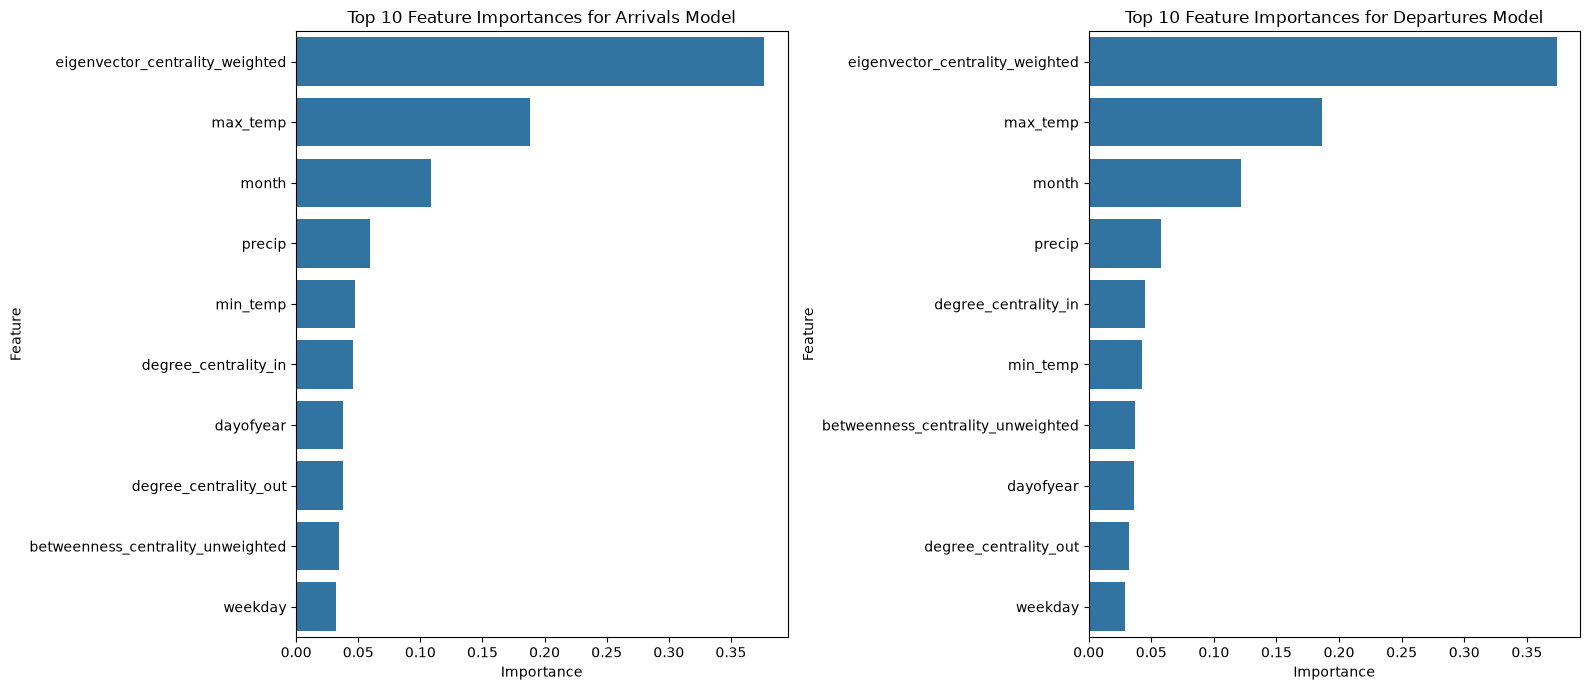

In [111]:
plt.figure(figsize=(16, 7))

# --- Feature Importance for Arrivals Model ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
feature_importances_arrivals = pd.DataFrame({
    'feature': X_train_arrivals.columns,
    'importance': xgb_arrivals_model.feature_importances_
}).sort_values(by='importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importances_arrivals.head(10))
plt.title('Top 10 Feature Importances for Arrivals Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

# --- Feature Importance for Departures Model ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
feature_importances_departures = pd.DataFrame({
    'feature': X_train_departures.columns,
    'importance': xgb_departures_model.feature_importances_
}).sort_values(by='importance', ascending=False)
sns.barplot(x='importance', y='feature', data=feature_importances_departures.head(10))
plt.title('Top 10 Feature Importances for Departures Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()


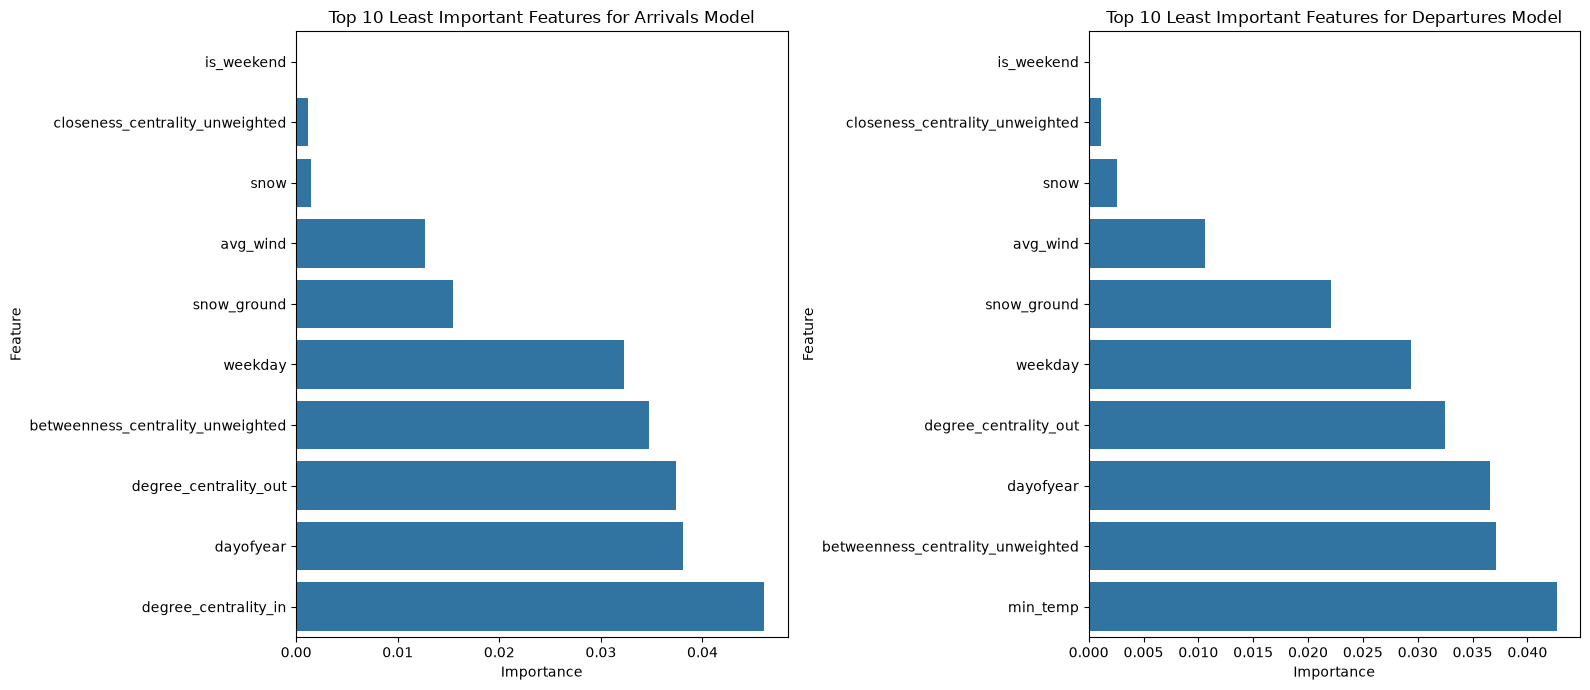

In [112]:
plt.figure(figsize=(16, 7))

# --- Feature Importance for Arrivals Model (Least Important) ---
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
feature_importances_arrivals_least = pd.DataFrame({
    'feature': X_train_arrivals.columns,
    'importance': xgb_arrivals_model.feature_importances_
}).sort_values(by='importance', ascending=True)
sns.barplot(x='importance', y='feature', data=feature_importances_arrivals_least.head(10))
plt.title('Top 10 Least Important Features for Arrivals Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

# --- Feature Importance for Departures Model (Least Important) ---
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
feature_importances_departures_least = pd.DataFrame({
    'feature': X_train_departures.columns,
    'importance': xgb_departures_model.feature_importances_
}).sort_values(by='importance', ascending=True)
sns.barplot(x='importance', y='feature', data=feature_importances_departures_least.head(10))
plt.title('Top 10 Least Important Features for Departures Model')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

In [113]:
print(f"Number of features for Arrivals model: {X_train_arrivals.shape[1]}")
print(f"Number of features for Departures model: {X_train_departures.shape[1]}")

Number of features for Arrivals model: 15
Number of features for Departures model: 15


In [114]:
X_train_arrivals.head()

,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
142124,3,223,8,0,0.875000,0.877907,0.001604,0.884885,0.085254,8.05,1.60,0.0,0.0,90.0,74.0
428115,1,6,1,0,0.656977,0.630814,0.000359,0.739663,0.009541,4.25,0.00,0.0,0.0,45.0,31.0
134349,0,178,6,0,0.645349,0.610465,0.000339,0.733245,0.009114,7.61,0.50,0.0,0.0,82.0,70.0
192603,3,131,5,0,0.886628,0.898256,0.003569,0.894249,0.113166,7.83,0.00,0.0,0.0,80.0,52.0
29798,3,219,8,0,0.845930,0.845930,0.001678,0.862312,0.024858,5.82,0.44,0.0,0.0,83.0,70.0


### Model Tuning: Hyperparameter Optimization with GridSearchCV

Hyperparameter tuning is crucial for getting the best performance out of your machine learning models. We'll use `GridSearchCV` to search for optimal `n_estimators`, `max_depth`, and `learning_rate` for the XGBoost Arrivals model.


In [115]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.01, 0.1, 0.2] # Step size shrinkage to prevent overfitting
}

# Initialize the XGBoost Regressor for Arrivals
# We use the same random_state for reproducibility
estimator_arrivals = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV
# We'll use MAE as the scoring metric (neg_mean_absolute_error for GridSearchCV)
# n_jobs=-1 uses all available CPU cores for parallel processing
print("\nStarting GridSearchCV for Arrivals model...")
grid_search_arrivals = GridSearchCV(
    estimator=estimator_arrivals,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error', # GridSearchCV tries to maximize the score, so we use negative MAE
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=1
)



Starting GridSearchCV for Arrivals model...


In [116]:


# Fit GridSearchCV to the training data
grid_search_arrivals.fit(X_train_arrivals, y_train_arrivals)
print("GridSearchCV for Arrivals model complete.")

# Print the best parameters and best MAE score found
print("\nBest parameters for Arrivals model:", grid_search_arrivals.best_params_)
# Note: best_score_ is negative MAE, so multiply by -1 to get actual MAE
print("Best MAE for Arrivals model:", -grid_search_arrivals.best_score_)

# Train a new XGBoost model for Arrivals with the best parameters
xgb_arrivals_model_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',
    **grid_search_arrivals.best_params_,
    random_state=42 # Ensure reproducibility
)

print("\nTraining tuned XGBoost model for Arrivals...")
xgb_arrivals_model_tuned.fit(X_train_arrivals, y_train_arrivals)
print("Tuned XGBoost model for Arrivals training complete.")

# Make predictions with the tuned model
y_pred_arrivals_tuned = xgb_arrivals_model_tuned.predict(X_test_arrivals)

# Ensure non-negative predictions for counts
y_pred_arrivals_tuned[y_pred_arrivals_tuned < 0] = 0





Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for Arrivals model complete.

Best parameters for Arrivals model: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best MAE for Arrivals model: 3.9204724288497643

Training tuned XGBoost model for Arrivals...
Tuned XGBoost model for Arrivals training complete.


In [117]:
# Evaluate the tuned model
mae_arrivals_tuned = mean_absolute_error(y_test_arrivals, y_pred_arrivals_tuned)
r2_arrivals_tuned = r2_score(y_test_arrivals, y_pred_arrivals_tuned)

print("\n--- Tuned XGBoost Model Performance (Arrivals) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_tuned:.3f}")
print(f"R-squared (R2): {r2_arrivals_tuned:.3f}")

# Compare with previous best (Ceiling Rounded)
print("\n--- Previous Best Arrivals Model Performance (Ceiling Rounded) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_ceil_rounded:.3f}")


--- Tuned XGBoost Model Performance (Arrivals) ---
Mean Absolute Error (MAE): 3.908
R-squared (R2): 0.800

--- Previous Best Arrivals Model Performance (Ceiling Rounded) ---
Mean Absolute Error (MAE): 4.542
R-squared (R2): 0.734


### Model Tuning: Hyperparameter Optimization with GridSearchCV for Departures

Now, let's apply `GridSearchCV` to tune the XGBoost Departures model. We'll use the same parameter grid and cross-validation strategy.

In [118]:
# Define the parameter grid to search (same as for Arrivals model)
param_grid_departures = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

In [119]:
# Initialize the XGBoost Regressor for Departures
estimator_departures = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

# Initialize GridSearchCV for Departures model
print("\nStarting GridSearchCV for Departures model...")
grid_search_departures = GridSearchCV(
    estimator=estimator_departures,
    param_grid=param_grid_departures,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the training data for Departures
grid_search_departures.fit(X_train_departures, y_train_departures)
print("GridSearchCV for Departures model complete.")


Starting GridSearchCV for Departures model...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
GridSearchCV for Departures model complete.


In [120]:
# Print the best parameters and best MAE score found for Departures model
print("\nBest parameters for Departures model:", grid_search_departures.best_params_)
print("Best MAE for Departures model:", -grid_search_departures.best_score_)

# Train a new XGBoost model for Departures with the best parameters
xgb_departures_model_tuned = xgb.XGBRegressor(
    objective='reg:squarederror',
    **grid_search_departures.best_params_,
    random_state=42
)

print("\nTraining tuned XGBoost model for Departures...")
xgb_departures_model_tuned.fit(X_train_departures, y_train_departures)
print("Tuned XGBoost model for Departures training complete.")


Best parameters for Departures model: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}
Best MAE for Departures model: 3.857624735094665

Training tuned XGBoost model for Departures...
Tuned XGBoost model for Departures training complete.


In [121]:
# Make predictions with the tuned Departures model
y_pred_departures_tuned = xgb_departures_model_tuned.predict(X_test_departures)

# Ensure non-negative predictions for counts
y_pred_departures_tuned[y_pred_departures_tuned < 0] = 0

# Evaluate the tuned Departures model
mae_departures_tuned = mean_absolute_error(y_test_departures, y_pred_departures_tuned)
r2_departures_tuned = r2_score(y_test_departures, y_pred_departures_tuned)

print("\n--- Tuned XGBoost Model Performance (Departures) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_tuned:.3f}")
print(f"R-squared (R2): {r2_departures_tuned:.3f}")

# Compare with previous best (Ceiling Rounded)
print("\n--- Previous Best Departures Model Performance (Ceiling Rounded) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_ceil_rounded:.3f}")


--- Tuned XGBoost Model Performance (Departures) ---
Mean Absolute Error (MAE): 3.846
R-squared (R2): 0.805

--- Previous Best Departures Model Performance (Ceiling Rounded) ---
Mean Absolute Error (MAE): 4.497
R-squared (R2): 0.739


### Detailed Error Analysis

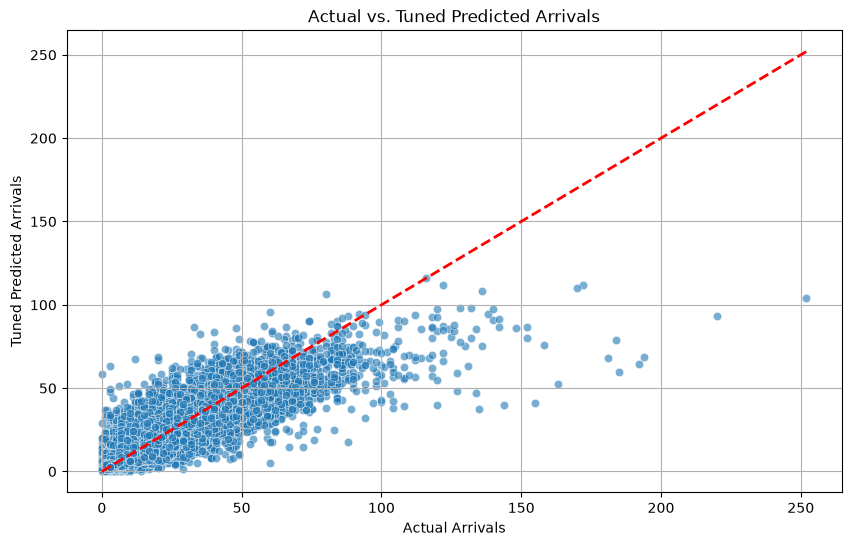

In [122]:
# --- Scatter Plot for Actual vs. Tuned Predicted Arrivals ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_arrivals, y=y_pred_arrivals_tuned, alpha=0.6)
plt.plot([min(y_test_arrivals), max(y_test_arrivals)], [min(y_test_arrivals), max(y_test_arrivals)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Tuned Predicted Arrivals')
plt.xlabel('Actual Arrivals')
plt.ylabel('Tuned Predicted Arrivals')
plt.grid(True)
plt.show()

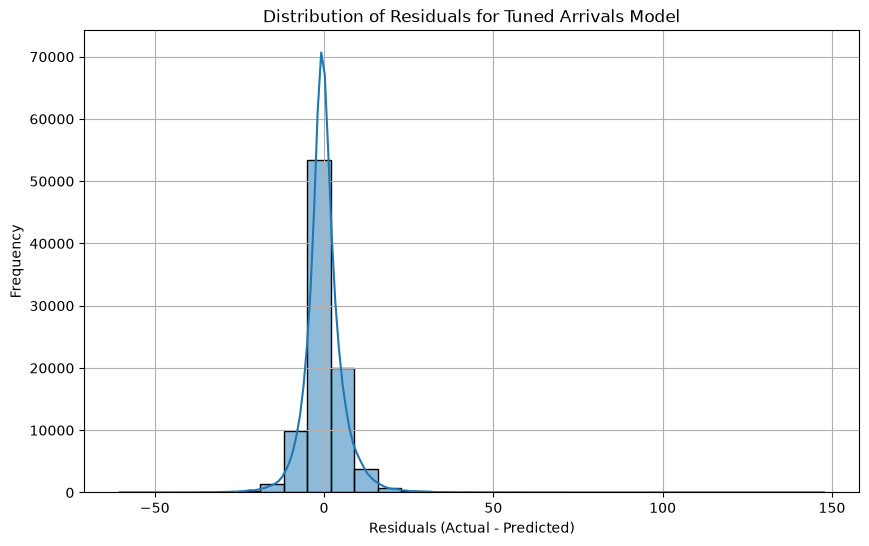

In [123]:
# --- Residuals Plot for Tuned Arrivals Model ---
residuals_arrivals_tuned = y_test_arrivals - y_pred_arrivals_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals_arrivals_tuned, bins=30, kde=True)
plt.title('Distribution of Residuals for Tuned Arrivals Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

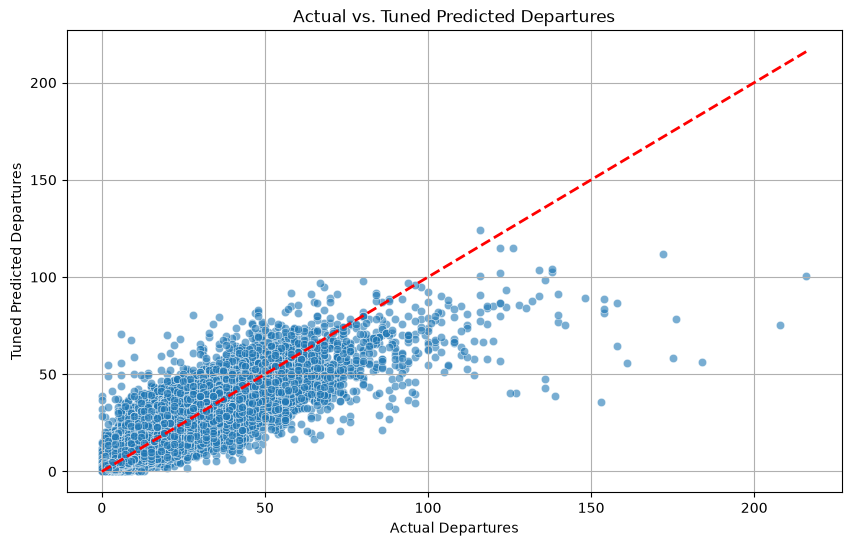

In [124]:
# --- Scatter Plot for Actual vs. Tuned Predicted Departures ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_departures, y=y_pred_departures_tuned, alpha=0.6)
plt.plot([min(y_test_departures), max(y_test_departures)], [min(y_test_departures), max(y_test_departures)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Tuned Predicted Departures')
plt.xlabel('Actual Departures')
plt.ylabel('Tuned Predicted Departures')
plt.grid(True)
plt.show()

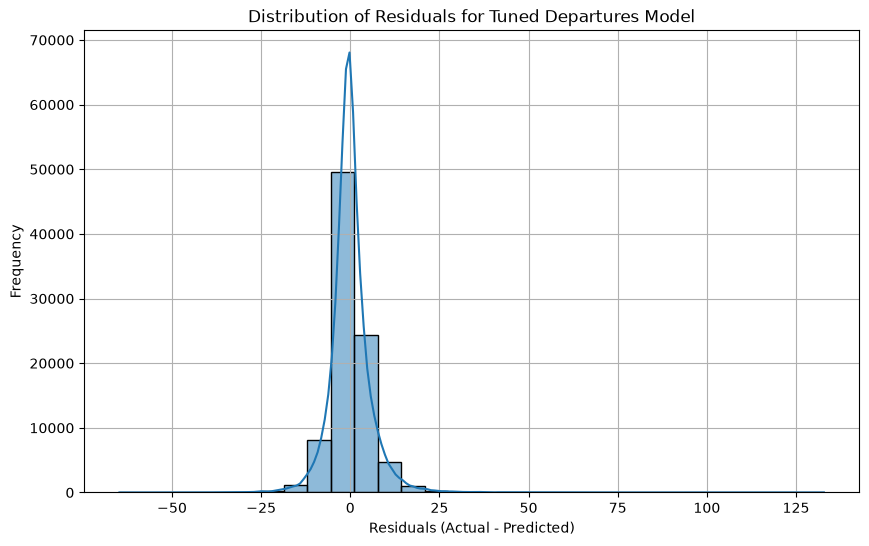

In [125]:
# --- Residuals Plot for Tuned Departures Model ---
residuals_departures_tuned = y_test_departures - y_pred_departures_tuned
plt.figure(figsize=(10, 6))
sns.histplot(residuals_departures_tuned, bins=30, kde=True)
plt.title('Distribution of Residuals for Tuned Departures Model')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

#### a large number of actual departures

may be throwing off the model.

In [126]:
# Sort the modeling_df by 'arrivals' in descending order and display the top 40
top_40_arrivals = modeling_df.sort_values(by='arrivals', ascending=False).head(40)

# Display only relevant columns for easier readability
display(top_40_arrivals[['date', 'station_id', 'arrivals', 'departures', 'net_change', 'weekday', 'is_weekend', 'max_temp', 'min_temp', 'precip']])

,date,station_id,arrivals,departures,net_change,weekday,is_weekend,max_temp,min_temp,precip
22443,2020-06-14,3057,288.0,288.0,0.0,6,True,77.0,56.0,0.00
89029,2021-09-25,3212,252.0,216.0,36.0,5,True,76.0,55.0,0.00
86954,2021-09-12,3212,238.0,212.0,26.0,6,True,86.0,64.0,0.00
19681,2020-05-25,3057,236.0,234.0,2.0,0,False,76.0,57.0,0.00
18431,2020-05-16,3057,231.0,225.0,6.0,5,True,79.0,60.0,0.00
20380,2020-05-30,3057,227.0,221.0,6.0,5,True,82.0,69.0,0.00
35084,2020-09-12,3212,222.0,228.0,-6.0,5,True,76.0,61.0,0.00
21479,2020-06-07,3057,220.0,208.0,12.0,6,True,80.0,65.0,0.00
33259,2020-08-30,3212,217.0,199.0,18.0,6,True,80.0,65.0,0.00
86006,2021-09-06,3212,214.0,206.0,8.0,0,False,85.0,69.0,0.03


In [127]:
aggregated_top_arrivals_by_station = top_40_arrivals.groupby('station_id').agg(
    total_arrivals=('arrivals', 'sum'),
    total_departures=('departures', 'sum'),
    avg_net_change=('net_change', 'mean'),
    count_occurrences=('station_id', 'size'),
    avg_max_temp=('max_temp', 'mean'),
    avg_min_temp=('min_temp', 'mean'),
    avg_precip=('precip', 'mean'),
    is_weekend_prevalence=('is_weekend', lambda x: (x.sum() / len(x)) * 100) # Percentage of occurrences on a weekend
).sort_values(by='total_arrivals', ascending=False)

display(aggregated_top_arrivals_by_station.head(10))

,total_arrivals,total_departures,avg_net_change,count_occurrences,avg_max_temp,avg_min_temp,avg_precip,is_weekend_prevalence
station_id,,,,,,,,
3057,3668.0,3563.0,5.833333,18,79.500000,60.388889,0.032778,83.333333
3212,1860.0,1753.0,11.888889,9,81.333333,63.777778,0.003333,88.888889
3208,1774.0,1498.0,27.600000,10,80.500000,62.800000,0.013000,0.000000
3010,174.0,186.0,-12.000000,1,70.000000,57.000000,0.000000,0.000000
3190,172.0,142.0,30.000000,1,76.000000,55.000000,0.000000,100.000000
3046,168.0,150.0,18.000000,1,85.000000,69.000000,0.030000,0.000000


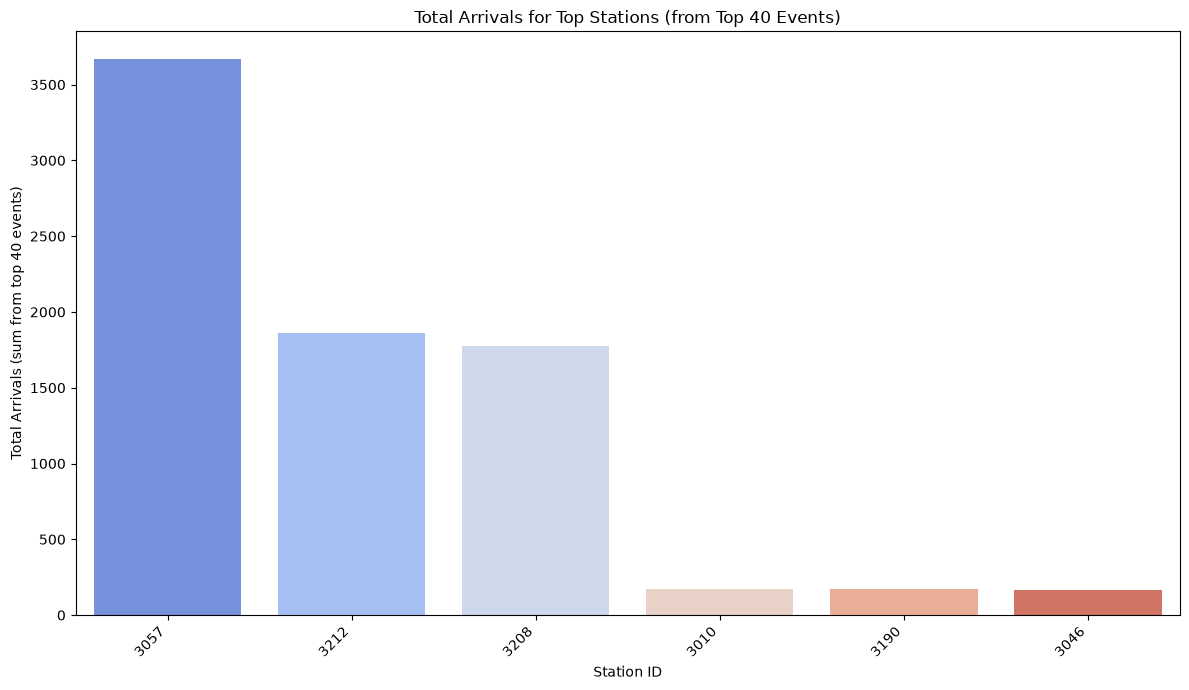

In [128]:
# Visualize the total arrivals by station for the aggregated top arrivals
plt.figure(figsize=(12, 7))
sns.barplot(x=aggregated_top_arrivals_by_station.index.astype(str), y='total_arrivals', data=aggregated_top_arrivals_by_station, palette='coolwarm', hue=aggregated_top_arrivals_by_station.index.astype(str), legend=False)
plt.title('Total Arrivals for Top Stations (from Top 40 Events)')
plt.xlabel('Station ID')
plt.ylabel('Total Arrivals (sum from top 40 events)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

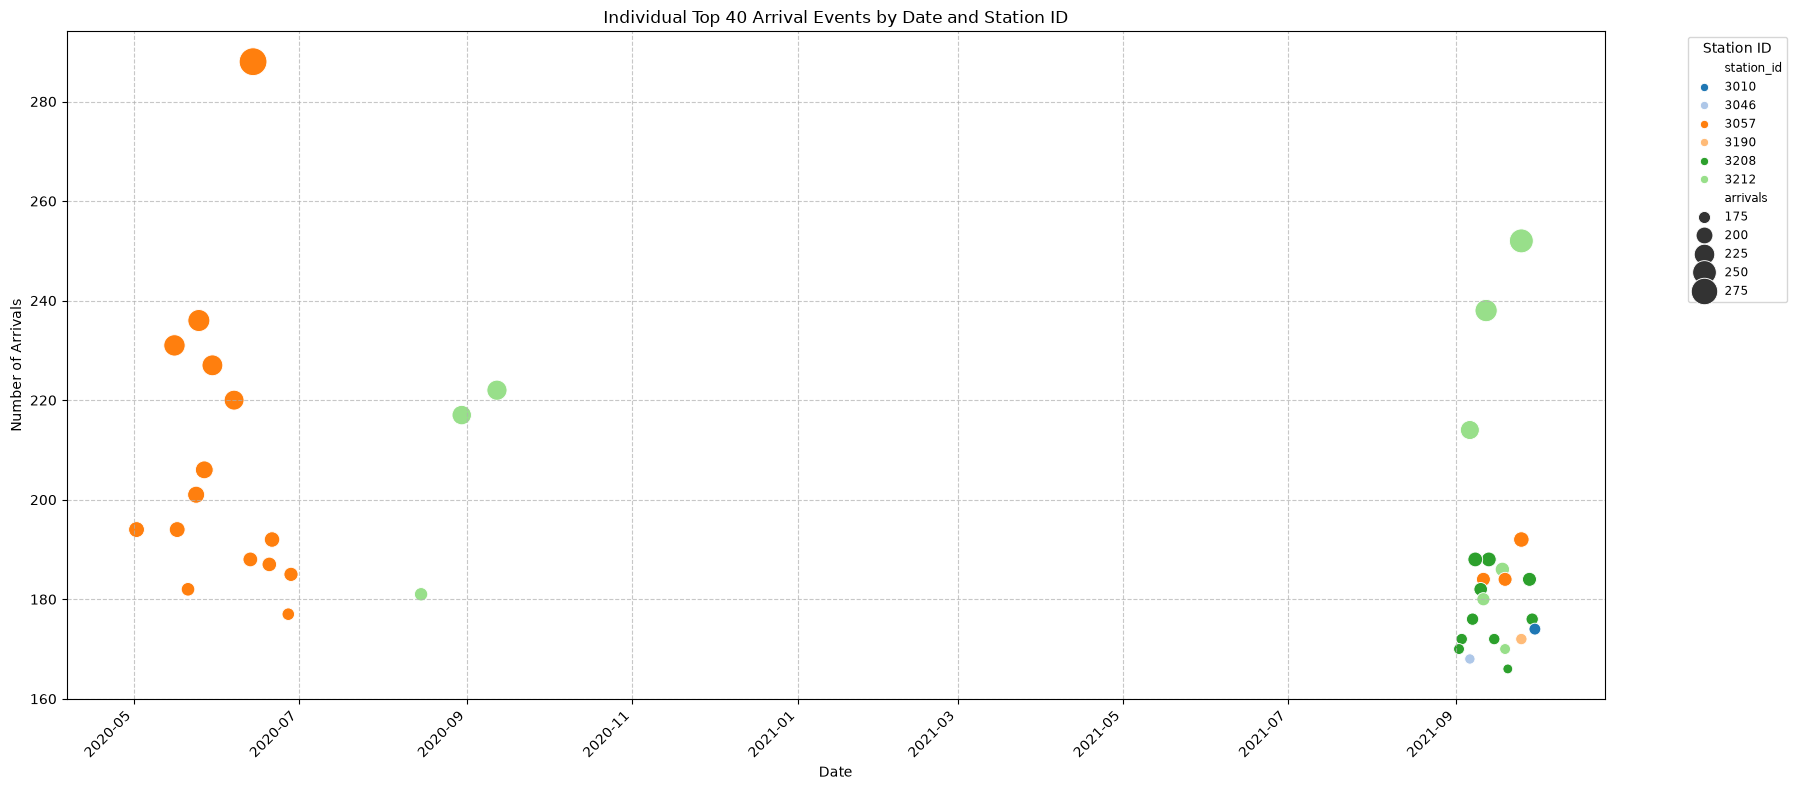

In [129]:
plt.figure(figsize=(18, 8))
sns.scatterplot(x='date', y='arrivals', hue='station_id', size='arrivals', sizes=(50, 400), data=top_40_arrivals, palette='tab20')
plt.title('Individual Top 40 Arrival Events by Date and Station ID')
plt.xlabel('Date')
plt.ylabel('Number of Arrivals')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Station ID', fontsize='small')
plt.tight_layout()
plt.show()

In [130]:
min_date = modeling_df['date'].min()
max_date = modeling_df['date'].max()
print(f"Date Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")

Date Range: 2020-01-01 to 2026-03-31


## For 2023-01-01 to 2026-3-31

In [131]:
modeling_df = modeling_df[(modeling_df['date'] >= '2023-01-01') & (modeling_df['date'] <= '2026-03-31')]

In [132]:
min_date = modeling_df['date'].min()
max_date = modeling_df['date'].max()
print(f"New Date Range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
display(modeling_df.head())

New Date Range: 2023-01-01 to 2026-03-31


,date,station_id,departures,arrivals,net_change,weekday,dayofyear,month,is_weekend,degree_centrality_in,degree_centrality_out,betweenness_centrality_unweighted,closeness_centrality_unweighted,eigenvector_centrality_weighted,avg_wind,precip,snow,snow_ground,max_temp,min_temp
167355,2023-01-01,3004,9.0,11.0,2.0,6,1,1,True,0.610465,0.607558,0.000245,0.714643,0.022472,7.61,0.0,0.0,0.0,57.0,39.0
167356,2023-01-01,3005,9.0,5.0,-4.0,6,1,1,True,0.834302,0.834302,0.001171,0.853601,0.051949,7.61,0.0,0.0,0.0,57.0,39.0
167357,2023-01-01,3006,8.0,6.0,-2.0,6,1,1,True,0.857558,0.845930,0.002645,0.871201,0.066821,7.61,0.0,0.0,0.0,57.0,39.0
167358,2023-01-01,3007,11.0,12.0,1.0,6,1,1,True,0.886628,0.895349,0.002138,0.894249,0.172888,7.61,0.0,0.0,0.0,57.0,39.0
167359,2023-01-01,3008,1.0,1.0,0.0,6,1,1,True,0.694767,0.764535,0.001102,0.761320,0.010123,7.61,0.0,0.0,0.0,57.0,39.0


### Modeling Arrivals with Reduced Date Range

In [133]:
# Define target for Arrivals model
target_arrivals = modeling_df['arrivals']

# Features for Arrivals model (exclude arrivals and departures and net_change)
features_arrivals = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_arrivals['is_weekend'] = features_arrivals['is_weekend'].astype(int)
print('Arrivals features and target redefined.')

Arrivals features and target redefined.


In [134]:
# Split data for Arrivals model
X_train_arrivals, X_test_arrivals, y_train_arrivals, y_test_arrivals = train_test_split(
    features_arrivals, target_arrivals, test_size=0.2, random_state=42
)

print("X_train_arrivals shape:", X_train_arrivals.shape)
print("X_test_arrivals shape:", X_test_arrivals.shape)
print("y_train_arrivals shape:", y_train_arrivals.shape)
print("y_test_arrivals shape:", y_test_arrivals.shape)

X_train_arrivals shape: (225822, 15)
X_test_arrivals shape: (56456, 15)
y_train_arrivals shape: (225822,)
y_test_arrivals shape: (56456,)


In [135]:
# Initialize and train the XGBoost Regressor for Arrivals
xgb_arrivals_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Arrivals...")
xgb_arrivals_model.fit(X_train_arrivals, y_train_arrivals)
print("XGBoost model for Arrivals training complete.")


Training XGBoost model for Arrivals...
XGBoost model for Arrivals training complete.


In [136]:
# Make predictions and round to nearest whole number (and ensure non-negative) for Arrivals
# 1. Normal predictions (raw output from the model)
y_pred_arrivals_normal = xgb_arrivals_model.predict(X_test_arrivals)

# 2. Standard Round predictions
y_pred_arrivals_standard_rounded = np.round(y_pred_arrivals_normal)
y_pred_arrivals_standard_rounded[y_pred_arrivals_standard_rounded < 0] = 0 # Ensure no negative predictions for counts

# 3. Floor Round predictions
y_pred_arrivals_floor_rounded = np.floor(y_pred_arrivals_normal)
y_pred_arrivals_floor_rounded[y_pred_arrivals_floor_rounded < 0] = 0 # Ensure no negative predictions for counts

# 4. Ceiling Round predictions
y_pred_arrivals_ceil_rounded = np.ceil(y_pred_arrivals_normal)
y_pred_arrivals_ceil_rounded[y_pred_arrivals_ceil_rounded < 0] = 0 # Ensure no negative predictions for counts

In [137]:
# Evaluate the Arrivals model

# 1. Normal Predictions
mae_arrivals_normal = mean_absolute_error(y_test_arrivals, y_pred_arrivals_normal)
r2_arrivals_normal = r2_score(y_test_arrivals, y_pred_arrivals_normal)

print("\n--- XGBoost Model Performance (Arrivals - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_normal:.3f}")
print(f"R-squared (R2): {r2_arrivals_normal:.3f}")

# 2. Standard Rounded Predictions
mae_arrivals_standard_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_standard_rounded)
r2_arrivals_standard_rounded = r2_score(y_test_arrivals, y_pred_arrivals_standard_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_standard_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_standard_rounded:.3f}")

# 3. Floor Rounded Predictions
mae_arrivals_floor_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_floor_rounded)
r2_arrivals_floor_rounded = r2_score(y_test_arrivals, y_pred_arrivals_floor_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_floor_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_floor_rounded:.3f}")

# 4. Ceiling Rounded Predictions
mae_arrivals_ceil_rounded = mean_absolute_error(y_test_arrivals, y_pred_arrivals_ceil_rounded)
r2_arrivals_ceil_rounded = r2_score(y_test_arrivals, y_pred_arrivals_ceil_rounded)

print("\n--- XGBoost Model Performance (Arrivals - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_arrivals_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_arrivals_ceil_rounded:.3f}")


--- XGBoost Model Performance (Arrivals - Normal Predictions) ---
Mean Absolute Error (MAE): 3.672
R-squared (R2): 0.823

--- XGBoost Model Performance (Arrivals - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 3.662
R-squared (R2): 0.822

--- XGBoost Model Performance (Arrivals - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 3.629
R-squared (R2): 0.821

--- XGBoost Model Performance (Arrivals - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 3.754
R-squared (R2): 0.821


### Modeling Departures with Reduced Date Range

In [138]:
# Define target for Departures model
target_departures = modeling_df['departures']

# Features for Departures model (exclude arrivals and departures and net_change)
features_departures = modeling_df.drop(columns=['date', 'departures', 'arrivals', 'net_change', 'station_id'])
features_departures['is_weekend'] = features_departures['is_weekend'].astype(int)
print('Departures features and target redefined.')

Departures features and target redefined.


In [139]:
# Split data for Departures model
X_train_departures, X_test_departures, y_train_departures, y_test_departures = train_test_split(
    features_departures, target_departures, test_size=0.2, random_state=42
)

print("X_train_departures shape:", X_train_departures.shape)
print("X_test_departures shape:", X_test_departures.shape)
print("y_train_departures shape:", y_train_departures.shape)
print("y_test_departures shape:", y_test_departures.shape)

X_train_departures shape: (225822, 15)
X_test_departures shape: (56456, 15)
y_train_departures shape: (225822,)
y_test_departures shape: (56456,)


In [140]:
# Initialize and train the XGBoost Regressor for Departures
xgb_departures_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

print("\nTraining XGBoost model for Departures...")
xgb_departures_model.fit(X_train_departures, y_train_departures)
print("XGBoost model for Departures training complete.")


Training XGBoost model for Departures...
XGBoost model for Departures training complete.


In [141]:
# Make predictions and round to nearest whole number (and ensure non-negative) for Departures
# 1. Normal predictions (raw output from the model)
y_pred_departures_normal = xgb_departures_model.predict(X_test_departures)

# 2. Standard Round predictions
y_pred_departures_standard_rounded = np.round(y_pred_departures_normal)
y_pred_departures_standard_rounded[y_pred_departures_standard_rounded < 0] = 0 # Ensure no negative predictions for counts

# 3. Floor Round predictions
y_pred_departures_floor_rounded = np.floor(y_pred_departures_normal)
y_pred_departures_floor_rounded[y_pred_departures_floor_rounded < 0] = 0 # Ensure no negative predictions for counts

# 4. Ceiling Round predictions
y_pred_departures_ceil_rounded = np.ceil(y_pred_departures_normal)
y_pred_departures_ceil_rounded[y_pred_departures_ceil_rounded < 0] = 0 # Ensure no negative predictions for counts

In [142]:
# Evaluate the Departures model

# 1. Normal Predictions
mae_departures_normal = mean_absolute_error(y_test_departures, y_pred_departures_normal)
r2_departures_normal = r2_score(y_test_departures, y_pred_departures_normal)

print("\n--- XGBoost Model Performance (Departures - Normal Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_normal:.3f}")
print(f"R-squared (R2): {r2_departures_normal:.3f}")

# 2. Standard Rounded Predictions
mae_departures_standard_rounded = mean_absolute_error(y_test_departures, y_pred_departures_standard_rounded)
r2_departures_standard_rounded = r2_score(y_test_departures, y_pred_departures_standard_rounded)

print("\n--- XGBoost Model Performance (Departures - Standard Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_standard_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_standard_rounded:.3f}")

# 3. Floor Rounded Predictions
mae_departures_floor_rounded = mean_absolute_error(y_test_departures, y_pred_departures_floor_rounded)
r2_departures_floor_rounded = r2_score(y_test_departures, y_pred_departures_floor_rounded)

print("\n--- XGBoost Model Performance (Departures - Floor Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_floor_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_floor_rounded:.3f}")

# 4. Ceiling Rounded Predictions
mae_departures_ceil_rounded = mean_absolute_error(y_test_departures, y_pred_departures_ceil_rounded)
r2_departures_ceil_rounded = r2_score(y_test_departures, y_pred_departures_ceil_rounded)

print("\n--- XGBoost Model Performance (Departures - Ceiling Rounded Predictions) ---")
print(f"Mean Absolute Error (MAE): {mae_departures_ceil_rounded:.3f}")
print(f"R-squared (R2): {r2_departures_ceil_rounded:.3f}")


--- XGBoost Model Performance (Departures - Normal Predictions) ---
Mean Absolute Error (MAE): 3.639
R-squared (R2): 0.827

--- XGBoost Model Performance (Departures - Standard Rounded Predictions) ---
Mean Absolute Error (MAE): 3.628
R-squared (R2): 0.826

--- XGBoost Model Performance (Departures - Floor Rounded Predictions) ---
Mean Absolute Error (MAE): 3.599
R-squared (R2): 0.824

--- XGBoost Model Performance (Departures - Ceiling Rounded Predictions) ---
Mean Absolute Error (MAE): 3.719
R-squared (R2): 0.825


that's a LOT of code to scroll through...

In [143]:
# Original Arrivals Model Metrics (from previous runs before filtering)
original_arrivals_metrics = {
    'Prediction Type': ['Normal', 'Standard Rounded', 'Floor Rounded', 'Ceiling Rounded'],
    'MAE': [0.503, 0.507, 0.533, 0.475],
    'R2': [-0.059, -1.000, -1.108, -0.859]
}
df_original_arrivals = pd.DataFrame(original_arrivals_metrics).set_index('Prediction Type')

# Filtered Arrivals Model Metrics (from current run)
filtered_arrivals_metrics = {
    'Prediction Type': ['Normal', 'Standard Rounded', 'Floor Rounded', 'Ceiling Rounded'],
    'MAE': [mae_arrivals_normal, mae_arrivals_standard_rounded, mae_arrivals_floor_rounded, mae_arrivals_ceil_rounded],
    'R2': [r2_arrivals_normal, r2_arrivals_standard_rounded, r2_arrivals_floor_rounded, r2_arrivals_ceil_rounded]
}
df_filtered_arrivals = pd.DataFrame(filtered_arrivals_metrics).set_index('Prediction Type')

print("### Arrivals Model Performance Comparison:")
pd.concat({'Original Data': df_original_arrivals, 'Filtered Data (2023-2026)': df_filtered_arrivals}, axis=1).round(3)

### Arrivals Model Performance Comparison:


Original Data        Filtered Data (2023-2026)       
                           MAE     R2                       MAE     R2
Prediction Type                                                       
Normal                   0.503 -0.059                     3.672  0.823
Standard Rounded         0.507 -1.000                     3.662  0.822
Floor Rounded            0.533 -1.108                     3.629  0.821
Ceiling Rounded          0.475 -0.859                     3.754  0.821

In [144]:
# Original Departures Model Metrics (from previous runs before filtering)
original_departures_metrics = {
    'Prediction Type': ['Normal', 'Standard Rounded', 'Floor Rounded', 'Ceiling Rounded'],
    'MAE': [0.506, 0.508, 0.512, 0.499],
    'R2': [-0.056, -0.961, -1.005, -0.910]
}
df_original_departures = pd.DataFrame(original_departures_metrics).set_index('Prediction Type')

# Filtered Departures Model Metrics (from current run)
filtered_departures_metrics = {
    'Prediction Type': ['Normal', 'Standard Rounded', 'Floor Rounded', 'Ceiling Rounded'],
    'MAE': [mae_departures_normal, mae_departures_standard_rounded, mae_departures_floor_rounded, mae_departures_ceil_rounded],
    'R2': [r2_departures_normal, r2_departures_standard_rounded, r2_departures_floor_rounded, r2_departures_ceil_rounded]
}
df_filtered_departures = pd.DataFrame(filtered_departures_metrics).set_index('Prediction Type')

print("### Departures Model Performance Comparison:")
pd.concat({'Original Data': df_original_departures, 'Filtered Data (2023-2026)': df_filtered_departures}, axis=1).round(3)

### Departures Model Performance Comparison:


Original Data        Filtered Data (2023-2026)       
                           MAE     R2                       MAE     R2
Prediction Type                                                       
Normal                   0.506 -0.056                     3.639  0.827
Standard Rounded         0.508 -0.961                     3.628  0.826
Floor Rounded            0.512 -1.005                     3.599  0.824
Ceiling Rounded          0.499 -0.910                     3.719  0.825